### 有還原字型

In [ ]:
# import pandas as pd
# import re, string
# import numpy as np
# np.random.seed(42)
# import spacy
# nlp = spacy.load("en_core_web_sm")
# stopwords = nlp.Defaults.stop_words

# data = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\BERTopic\bbc-news-data.csv', sep='\t')

# def preprocess(text):
#     text = text.lower()  # 轉成小寫
#     text = re.sub(r'\d+', '', text)  # 移除數字
#     text = re.sub(r'[^\w\s]', '', text)  # 移除標點符號
#     text = re.sub(r'\s+', ' ', text).strip()  # 移除多餘空白
    
#     doc = nlp(text)
#     lemmatized_tokens = [token.lemma_ for token in doc if token.is_alpha and token.lemma_ not in stopwords and len(token.lemma_) > 1]
#     return lemmatized_tokens

# data['Tokens'] = data['content'].apply(preprocess)
# data['cleaned_content'] = data['Tokens'].apply(lambda x: ' '.join(x))
# data.to_csv('BBCnews_cleaned.csv', encoding='utf-8-sig')

### 沒有還原字型

In [ ]:
# import pandas as pd
# import re, string
# import numpy as np
# np.random.seed(42)
# # 下載並設定停用詞
# import nltk
# from nltk.corpus import stopwords
# nltk.download('stopwords')
# stop_words = stopwords.words('english')
# custom_stop = {'said', 'mr', 'also', 'would', 'new', 'one', 'like', 'could', 'us', 'many', 'get', 'use', 'two', 'first',
#                'told', 'say', 'may', 'good', 'last', 'make', 'well', 'next'}
# all_stopwords = set(stop_words).union(custom_stop)

# data = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\BERTopic\bbc-news-data.csv', sep='\t')

# def preprocess(text):
#     text = text.lower()  # 轉成小寫
#     text = re.sub(r'\d+', '', text)  # 移除數字
#     text = re.sub(r'[^\w\s]', '', text)  # 移除標點符號
#     text = re.sub(r'\s+', ' ', text).strip()  # 移除多餘空白
#     text = ' '.join([word for word in text.split() if word not in all_stopwords])  # 移除停用詞
#     return text

# data['cleaned_content'] = data['content'].apply(preprocess)
# data['Tokens'] = data['cleaned_content'].apply(lambda x: x.split())

### 算文章的tfidf來設定seed

In [ ]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# for label in data['category'].unique():
#     docs = data[data['category'] == label]['cleaned_content']
#     vec = TfidfVectorizer(max_df=0.8, min_df=5, stop_words='english')
#     tfidf = vec.fit_transform(docs)
#     top_words = sorted(zip(vec.get_feature_names_out(), 
#                            tfidf.sum(axis=0).A1),
#                            key=lambda x: -x[1])[:30]
#     print(f'\'{label}\': {[w for w, _ in top_words]}' +',')

In [ ]:
# seed = {
# 'business': ['bn', 'year', 'company', 'mr', 'firm', 'sale', 'rise', 'bank', 'market', 'share', 'price', 'growth', 'economy', 'rate', 'government', 'new', 'fall', 'oil', 'economic', 'profit', 'report', 'month', 'analyst', 'business', 'high', 'expect', 'dollar', 'figure', 'deal', 'world'],
# 'entertainment': ['film', 'good', 'award', 'year', 'star', 'music', 'win', 'band', 'include', 'number', 'new', 'album', 'festival', 'actor', 'play', 'mr', 'oscar', 'director', 'chart', 'tv', 'uk', 'bbc', 'record', 'song', 'million', 'time', 'release', 'british', 'people', 'singer'],
# 'politics': ['mr', 'labour', 'election', 'party', 'blair', 'government', 'tory', 'people', 'minister', 'lord', 'brown', 'plan', 'howard', 'tax', 'new', 'tell', 'year', 'chancellor', 'prime', 'public', 'britain', 'uk', 'home', 'mp', 'campaign', 'country', 'issue', 'vote', 'leader', 'work'],
# 'sport': ['win', 'play', 'game', 'england', 'player', 'good', 'year', 'world', 'club', 'match', 'time', 'team', 'come', 'cup', 'champion', 'second', 'injury', 'think', 'wale', 'ireland', 'open', 'season', 'want', 'coach', 'final', 'chelsea', 'rugby', 'set', 'new', 'france'],
# 'tech': ['game', 'people', 'mobile', 'phone', 'use', 'technology', 'service', 'mr', 'user', 'music', 'software', 'new', 'computer', 'year', 'site', 'digital', 'firm', 'network', 'net', 'broadband', 'microsoft', 'player', 'search', 'million', 'email', 'online', 'company', 'tv', 'program', 'pc'],
# }


In [ ]:

# selected_tokens = set()
# for words in seed.values():
#     selected_tokens.update(words)

# from sklearn.feature_extraction.text import CountVectorizer

# vectorizer = CountVectorizer(vocabulary=list(selected_tokens))
# X = vectorizer.fit_transform(data['cleaned_content'])

# tf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
# tf_df.to_csv("還原字型0.8_5的tfidf前30.txt", index=False, sep='\t')


---

---

In [1]:
import pandas as pd
data = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\BERTopic\BBCnews_cleaned.csv')
# 你把 list 存成 .csv 之後，pandas.read_csv 會把它當成 字串，不會還原回原本的 list。
# 所以
import ast
data['Tokens'] = data['Tokens'].apply(ast.literal_eval)
texts = data['Tokens']

In [2]:
data['category'].value_counts()

category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

---

---

1️⃣ Stage 1：Baseline LDA 建模

原始文本 → 詞彙表 + TF → gensim LDA 模型

                         　 　↓
             　　　　　　　產生 doc-topic 分布 θ_d
                         　 　↓
            　　　　　　 　搭配 TF 建立 token vector（P × K）

──────────────────────────────

2️⃣ Stage 2：GAP 結構導入 + η 建構

GAP token 分群（人工 / 自動）

               ↓
          每群 token vector → 計算 cluster center
               ↓
          每個 token 計算與各 cluster 的相似度
               ↓
          相似度 → softmax（產生 soft η: K × V）

──────────────────────────────

3️⃣ 再訓練 LDA 模型（GAP 引導）

gensim LDA with eta=η
→ GAP-informed 主題模型
→ 更語意一致的 topic-word 分布與文件主題分配


In [4]:
from gensim.corpora import Dictionary
from gensim.models.ldamodel import LdaModel
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
import pandas as pd
import numpy as np

# === 1. 建立字典與語料 ===
dictionary = Dictionary(data['Tokens'])
corpus = [dictionary.doc2bow(tokens) for tokens in data['Tokens']]

# === 2. 建立 TF 矩陣（P x N） ===
tf_df = pd.DataFrame(0, index=dictionary.token2id.keys(), columns=range(len(data)))
for doc_id, tokens in enumerate(data['Tokens']):
    for token in tokens:
        if token in tf_df.index:
            tf_df.loc[token, doc_id] += 1

tf_matrix = tf_df.values  # P × N
V = len(dictionary)

# === 3. 讀取 token 分群（GAP） ===
token_df = pd.read_csv(r'C:\Users\USER\Documents\GitHub\psychic-spoon\還原字型0.8_5的tfidf前30手動分群.csv')
token_df = token_df[token_df['token'].isin(dictionary.token2id)].reset_index(drop=True)

# 重新建立 token_index（對應 tf_df 的 index）
token_index_map = {token: idx for idx, token in enumerate(tf_df.index)}
token_df['token_idx'] = token_df['token'].map(token_index_map)

# === 4. 建立 token_vectors：每個 token 在 topic 空間的語意向量 ===
K = 5  # 預設 topic 數
lda_baseline = LdaModel(corpus=corpus, id2word=dictionary, num_topics=K, random_state=42)
lda_probs = np.array([[prob for _, prob in lda_baseline.get_document_topics(doc, minimum_probability=0)] for doc in corpus])

token_vectors = tf_matrix @ lda_probs  # P × K
token_sums = tf_matrix.sum(axis=1, keepdims=True)
token_sums[token_sums == 0] = 1e-10
token_vectors = token_vectors / token_sums
token_vectors = normalize(token_vectors, axis=1)

# === 5. 建 GAP topic → LDA topic mapping ===
gap_topics = sorted(token_df['topic'].unique())
gap_to_lda = {gap_k: lda_k for lda_k, gap_k in enumerate(gap_topics)}

# === 6. GAP cluster centers ===
cluster_centers = []
for gap_k in gap_topics:
    cluster_token_idx = token_df[token_df['topic'] == gap_k]['token_idx']
    cluster_vecs = token_vectors[cluster_token_idx]

    if len(cluster_vecs) == 0:
        center = np.random.rand(K)
    else:
        center = cluster_vecs.mean(axis=0)

    center /= (np.linalg.norm(center) + 1e-10)
    cluster_centers.append(center)

cluster_centers = np.vstack(cluster_centers)

# === 7. 建立 η 矩陣（K × V） ===
eta_rows = []

for i in range(V):
    vec = token_vectors[i]
    similarities = cosine_similarity([vec], cluster_centers)[0]
    temp = 10
    similarities = np.clip(similarities, 1e-6, 1.0)
    soft_weights = np.exp(temp * similarities)
    soft_weights /= soft_weights.sum()
    eta_rows.append(soft_weights)

eta = np.array(eta_rows).T  # K × V

# === 8. 建立 LDA 模型 ===
lda = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=K,
    eta=eta,
    random_state=42,
    iterations=100,
    passes=10,
    alpha=0.1
)

# === 9. 顯示主題結果 ===
print("\n每個主題的前 20 詞：")
for k in range(K):
    top_words = lda.show_topic(k, topn=20)
    print(f"Topic {k+1}: {[w for w, _ in top_words]}")

# === 10. 顯示 η 中有套用 GAP 的 token 數量 ===
covered_words = [w for w in token_df['token'] if w in dictionary.token2id]
print(f"\n你的 GAP 分群中共 {len(token_df)} 個 token，其中 {len(covered_words)} 個成功對應到 dictionary。")



每個主題的前 20 詞：
Topic 1: ['game', 'use', 'search', 'people', 'user', 'release', 'system', 'console', 'software', 'computer', 'new', 'mr', 'year', 'work', 'technology', 'title', 'nintendo', 'site', 'sony', 'time']
Topic 2: ['film', 'year', 'bn', 'company', 'sale', 'market', 'million', 'new', 'price', 'rise', 'firm', 'high', 'growth', 'expect', 'world', 'share', 'bank', 'china', 'figure', 'analyst']
Topic 3: ['mr', 'year', 'win', 'good', 'new', 'play', 'come', 'time', 'tell', 'world', 'government', 'labour', 'game', 'party', 'plan', 'think', 'election', 'want', 'add', 'england']
Topic 4: ['people', 'use', 'technology', 'phone', 'mobile', 'service', 'music', 'digital', 'new', 'user', 'firm', 'mr', 'year', 'network', 'tv', 'net', 'pc', 'computer', 'player', 'consumer']
Topic 5: ['people', 'email', 'use', 'spam', 'mr', 'site', 'law', 'government', 'online', 'legal', 'play', 'game', 'world', 'information', 'work', 'time', 'website', 'public', 'court', 'company']

你的 GAP 分群中共 123 個 token，其中 123

---

---

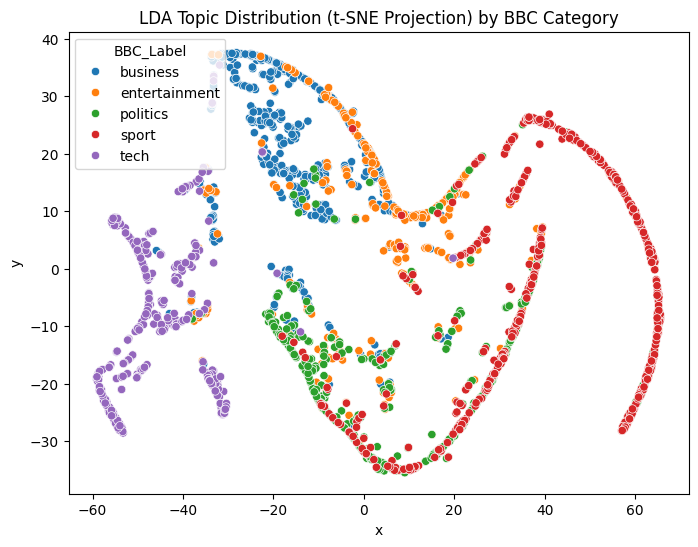

In [5]:
import pandas as pd

doc_topics = lda.get_document_topics(corpus, minimum_probability=0)

topic_distributions = pd.DataFrame([
    [prob for _, prob in doc] for doc in doc_topics
])

K = 5
topic_distributions.columns = [f"Topic_{i+1}" for i in range(K)]
topic_distributions['BBC_Label'] = data['category'].values

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(topic_distributions.iloc[:, :K].values)

topic_distributions['x'] = X_embedded[:, 0]
topic_distributions['y'] = X_embedded[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=topic_distributions, x='x', y='y', hue='BBC_Label', palette='tab10')
plt.title('LDA Topic Distribution (t-SNE Projection) by BBC Category')
plt.show()


In [6]:
# 拿每篇文件的 topic 分布（含所有 topic，minimum_probability=0 確保每個都有出現）
doc_topics = lda.get_document_topics(corpus, minimum_probability=0)

topic_distributions = pd.DataFrame([[prob for _, prob in doc] for doc in doc_topics])
topic_distributions.columns = [f"Topic_{i+1}" for i in range(K)]  # 從 1 開始好看一點
topic_distributions['BBC_Label'] = data['category'].values  # 加上原 BBC 分類方便比對

print(topic_distributions.head())


    Topic_1   Topic_2   Topic_3   Topic_4   Topic_5 BBC_Label
0  0.000478  0.811092  0.020720  0.167232  0.000478  business
1  0.000527  0.656422  0.322255  0.020270  0.000527  business
2  0.000729  0.472870  0.428581  0.000729  0.097092  business
3  0.000497  0.889441  0.109067  0.000497  0.000497  business
4  0.000716  0.412192  0.585661  0.000716  0.000716  business


In [7]:
mean_distribution_per_label = topic_distributions.groupby('BBC_Label').mean()
print(mean_distribution_per_label.T) 

BBC_Label  business  entertainment  politics     sport      tech
Topic_1    0.026265       0.023806  0.006803  0.006208  0.222611
Topic_2    0.507875       0.174710  0.023373  0.004691  0.057961
Topic_3    0.320002       0.697746  0.722951  0.929595  0.052829
Topic_4    0.041540       0.047651  0.016112  0.005968  0.535828
Topic_5    0.104319       0.056087  0.230761  0.053538  0.130771


In [8]:
topic_distributions

,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,BBC_Label
0,0.000478,0.811092,0.020720,0.167232,0.000478,business
1,0.000527,0.656422,0.322255,0.020270,0.000527,business
2,0.000729,0.472870,0.428581,0.000729,0.097092,business
3,0.000497,0.889441,0.109067,0.000497,0.000497,business
4,0.000716,0.412192,0.585661,0.000716,0.000716,business
...,...,...,...,...,...,...
2220,0.000464,0.000464,0.000464,0.998143,0.000464,tech
2221,0.000545,0.000545,0.000545,0.268759,0.729605,tech
2222,0.000216,0.000216,0.000216,0.408568,0.590784,tech
2223,0.000537,0.000537,0.000537,0.944376,0.054014,tech


In [9]:
from scipy.spatial.distance import cdist
from sklearn.metrics import accuracy_score, classification_report, adjusted_rand_score

# 1️⃣ 準備 one-hot topic vectors
one_hot_topics = np.eye(K)  # 產生 K x K 單位矩陣，每一列就是一個 one-hot vector

# 2️⃣ 將原 dataframe 的 LDA topic 機率轉為 numpy array
lda_probs = topic_distributions.iloc[:, :K].values  # 取前 K 欄 (Topic_1, Topic_2...)

# 3️⃣ 計算每個文件對每個 one-hot 的距離
distances = cdist(lda_probs, one_hot_topics, metric='euclidean')  # (N x K)

# 4️⃣ 找出最小距離的 one-hot index，視為該文件屬於該 topic
pred_topic_by_distance = np.argmin(distances, axis=1)+1 # 1-based topic index

# 5️⃣ BBC label 轉成數值 (0 ~ 4)，方便比較
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
true_label = le.fit_transform(data['category'])

# # 6️⃣ 評估效果
# acc = accuracy_score(true_label, pred_topic_by_distance)
# ari = adjusted_rand_score(true_label, pred_topic_by_distance)
# report = classification_report(true_label, pred_topic_by_distance, target_names=le.classes_)

# print("\nAccuracy:", round(acc, 4))
# print("Adjusted Rand Index (ARI):", round(ari, 4))
# print("\nClassification Report:\n", report)


In [10]:
pred_topic_by_distance

array([2, 2, 2, ..., 5, 4, 5], dtype=int64)

In [11]:
import numpy as np
import pandas as pd

mapped_df = pd.DataFrame({
    'true_label': data['category'].values,
    'pred_topic': pred_topic_by_distance
})

print(mapped_df.groupby(['true_label', 'pred_topic']).size())


true_label     pred_topic
business       1               7
               2             302
               3             158
               4              15
               5              28
entertainment  1               1
               2              40
               3             330
               4               9
               5               6
politics       1               1
               2               3
               3             361
               4               1
               5              51
sport          3             508
               5               3
tech           1              91
               2              16
               3               9
               4             226
               5              59
dtype: int64


In [12]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cdist

# 你的 LDA topic 分布（N x K matrix）
lda_probs = topic_distributions.iloc[:, :K].values

# ground truth label to one-hot (vec-y)
N = len(true_label)
K = len(le.classes_)

Y_onehot = np.zeros((N, K))
Y_onehot[np.arange(N), true_label] = 1

from sklearn.metrics.pairwise import cosine_similarity

consistency_scores = []

for y_true, y_hat in zip(Y_onehot, lda_probs):
    score = cosine_similarity([y_true], [y_hat])[0][0]
    consistency_scores.append(score)

print("Average Consistency (y vs y_hat):", round(np.mean(consistency_scores), 4))

category_centroids = {}

for idx, label in enumerate(le.classes_):
    mask = (true_label == idx)
    centroid = lda_probs[mask].mean(axis=0)
    category_centroids[label] = centroid

centroid_matrix = np.vstack(list(category_centroids.values()))

# 類別中心兩兩 cosine 相似度
similarity_matrix = cosine_similarity(centroid_matrix)

# 類別中心兩兩 L2 距離
distance_matrix = cdist(centroid_matrix, centroid_matrix, metric='euclidean')

centroid_df = pd.DataFrame(similarity_matrix, index=le.classes_, columns=le.classes_)
print("\nCategory Center Cosine Similarity:")
print(centroid_df)

distance_df = pd.DataFrame(distance_matrix, index=le.classes_, columns=le.classes_)
print("\nCategory Center L2 Distance:")
print(distance_df)


Average Consistency (y vs y_hat): 0.2511

Category Center Cosine Similarity:
               business  entertainment  politics     sport      tech
business       1.000000       0.724702  0.577609  0.537338  0.240213
entertainment  0.724702       1.000000  0.950824  0.969159  0.196203
politics       0.577609       0.950824  1.000000  0.968136  0.175305
sport          0.537338       0.969159  0.968136  1.000000  0.109125
tech           0.240213       0.196203  0.175305  0.109125  1.000000

Category Center L2 Distance:
               business  entertainment  politics     sport      tech
business       0.000000       0.506022  0.643524  0.793123  0.746576
entertainment  0.506022       0.000000  0.235230  0.291057  0.844373
politics       0.643524       0.235230  0.000000  0.273060  0.881439
sport          0.793123       0.291057  0.273060  0.000000  1.051239
tech           0.746576       0.844373  0.881439  1.051239  0.000000


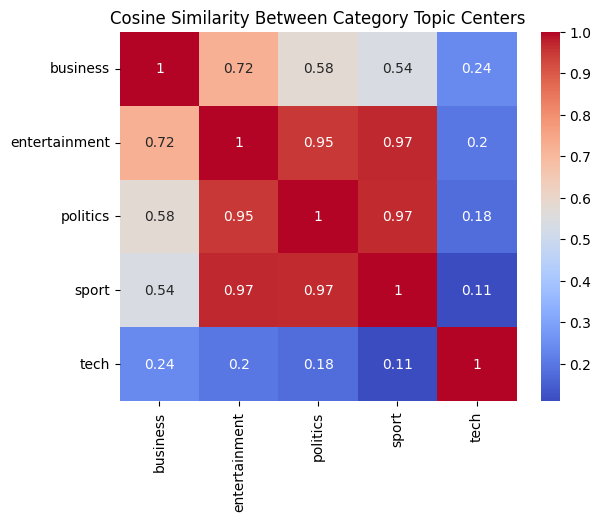

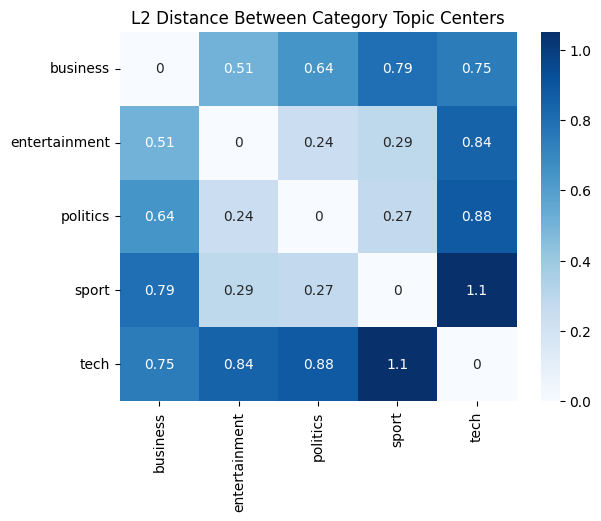

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(centroid_df, annot=True, cmap='coolwarm')
plt.title("Cosine Similarity Between Category Topic Centers")
plt.show()

sns.heatmap(distance_df, annot=True, cmap='Blues')
plt.title("L2 Distance Between Category Topic Centers")
plt.show()


---

---

### 原版LDA, 甚麼都不加, 只有token的訊息和基本參數設定

In [14]:
# import pandas as pd
# from sklearn.feature_extraction.text import CountVectorizer
# from gensim import corpora
# from gensim.models import LdaModel, CoherenceModel

# data = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\BERTopic\BBCnews_cleaned.csv')
# texts = data['Tokens'].apply(eval).tolist()

# dictionary = corpora.Dictionary(texts)
# corpus = [dictionary.doc2bow(text) for text in texts]

# vectorizer = CountVectorizer(analyzer=lambda x: x)
# doc_term_matrix = vectorizer.fit_transform(texts)

# lda_gensim = LdaModel(corpus=corpus, num_topics=5, id2word=dictionary, random_state=0)

# coherence_model = CoherenceModel(model=lda_gensim, texts=texts, dictionary=dictionary, coherence='c_v')
# print('gensim coherence:', coherence_model.get_coherence())

# # 取得 gensim LDA 每篇文章對 topic 的機率分佈
# doc_topic_gensim = np.array([
#     [prob for _, prob in lda_gensim.get_document_topics(doc, minimum_probability=0)] 
#     for doc in corpus
# ])

# # 準備 one-hot 真實分類
# N = len(true_label)
# K = lda_gensim.num_topics  # 確保 K 取自 gensim
# Y_onehot = np.zeros((N, K))
# Y_onehot[np.arange(N), true_label] = 1

# # 計算 consistency
# from sklearn.metrics.pairwise import cosine_similarity
# from scipy.spatial.distance import cdist

# lda_probs = doc_topic_gensim
# consistency_scores = [cosine_similarity([y_true], [y_hat])[0][0] for y_true, y_hat in zip(Y_onehot, lda_probs)]
# print("\nGensim - Average Consistency:", round(np.mean(consistency_scores), 4))

# # 每個類別計算 topic 機率的 centroid
# category_centroids = {}
# for idx, label in enumerate(le.classes_):
#     mask = (true_label == idx)
#     centroid = lda_probs[mask].mean(axis=0)
#     category_centroids[label] = centroid

# # 計算 Cosine 與 L2 距離
# centroid_matrix = np.vstack(list(category_centroids.values()))
# similarity_matrix = cosine_similarity(centroid_matrix)
# distance_matrix = cdist(centroid_matrix, centroid_matrix, metric='euclidean')

# print("\nGensim - Cosine Similarity:")
# print(pd.DataFrame(similarity_matrix, index=le.classes_, columns=le.classes_))
# print("\nGensim - L2 Distance:")
# print(pd.DataFrame(distance_matrix, index=le.classes_, columns=le.classes_))
